# Confidence Interval Using T-Procedure (Random Sample)

#### Objective
- In this notebook, we have the complete Titanic dataset, but we pretend that we don't know the population standard deviation. We randomly select a sample of 100 passengers and use only the sample statistics. This helps us understand how the T-Procedure works in real-world situations where the population information is not available.  


- The goal is to estimate the average age of all Titanic passengers by using a random sample instead of the whole dataset.
- Since the population standard deviation is unknown, we use the T-Procedure to calculate the confidence interval.

#### Why do we take a random sample?
- In real life, we usually cannot collect data from every person in a population. So, we take a small random sample and use it to estimate the population.
#### In this notebook:
- The Titanic dataset is treated as the population.
- We randomly select 100 passengers as our sample.
- Then, we calculate the confidence interval using this sample.

#### Why do we use the T-Procedure?
We use the T-Procedure when:  
- The population standard deviation (σ) is unknown.
- We have a random sample from the population.
- We want to estimate the population mean.
- The sample size is 30 or more, or the sample data is approximately normal.

# 

In [2]:
import seaborn as sns
import numpy as np
from scipy.stats import t

In [3]:
df = sns.load_dataset("titanic")

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
population = df["age"].dropna()

In [9]:
population.isnull().sum()

np.int64(0)

In [12]:
population.shape

(714,)

<Axes: xlabel='age', ylabel='Count'>

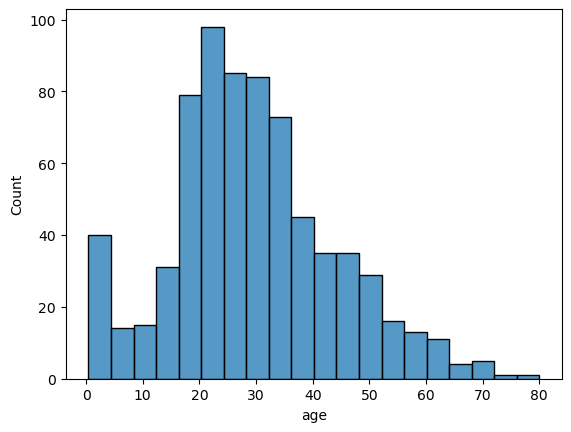

In [13]:
sns.histplot(population)

<Axes: xlabel='age', ylabel='Density'>

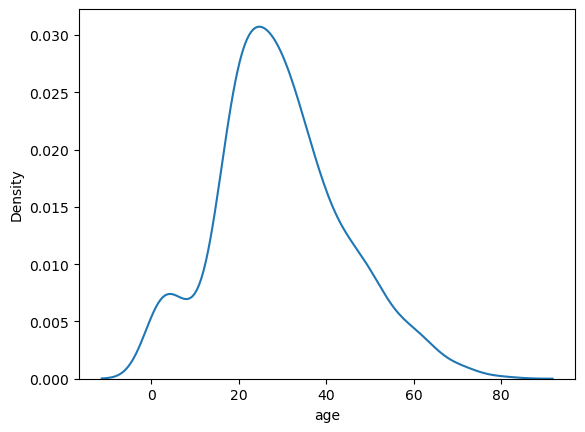

In [14]:
sns.kdeplot(population)

# 

In [16]:
sample = population.sample(n=100, random_state=42)

<Axes: xlabel='age', ylabel='Count'>

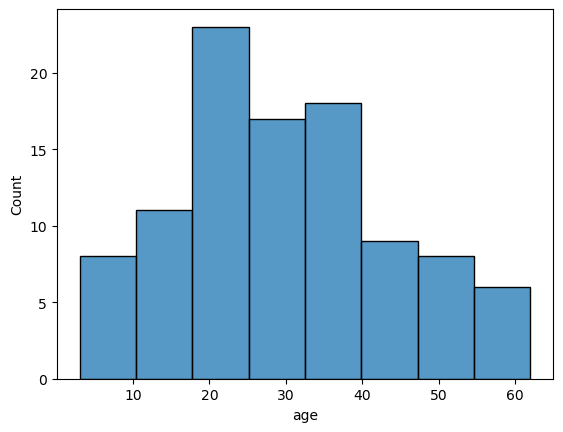

In [18]:
sns.histplot(sample)

# 

#### Manual Calculation

In [20]:
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)     

In [21]:
sample_mean

np.float64(30.045)

In [22]:
sample_std

14.106394960721849

In [25]:
n = len(sample)
se = sample_std / np.sqrt(n) 

In [26]:
se

np.float64(1.4106394960721849)

In [29]:
confidence = 0.95
alpha = 1 - confidence

In [30]:
alpha

0.050000000000000044

In [32]:
t_critical = t.ppf(1 - alpha/2, df=n-1)

In [33]:
t_critical

np.float64(1.9842169515086827)

In [34]:
margin_error = t_critical * se

In [36]:
margin_error

np.float64(2.799014800574095)

In [38]:
lower = sample_mean - margin_error
upper = sample_mean + margin_error

In [39]:
lower

np.float64(27.245985199425906)

In [40]:
upper

np.float64(32.844014800574094)

In [42]:
print(f" 95% Confidence Interval = ({lower:.2f} -  {upper:.2f})")

 95% Confidence Interval = (27.25 -  32.84)


In [43]:
sample_mean

np.float64(30.045)

In [44]:
population.mean()

np.float64(29.69911764705882)

# 

#### Using SciPy Built-in Function

In [47]:
ci = t.interval(
    confidence=0.95,
    df=n-1,
    loc=sample_mean,
    scale=se
)

print("95% Confidence Interval:", ci)

95% Confidence Interval: (np.float64(27.245985199425906), np.float64(32.844014800574094))


In [49]:
print('Population Mean : ',population.mean())
print('Sample Mean : ',sample_mean)

Population Mean :  29.69911764705882
Sample Mean :  30.045
